In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score
from scipy.stats import mannwhitneyu

In [15]:
BASE_DIR     = Path("/Users/bgadmin/Downloads/multiomics_preproc")
CLUSTER_DIR  = BASE_DIR / "clustering_leiden_A"
CLUSTERS_DIR = CLUSTER_DIR / "clusters_by_group"
SUBTYPE_DIR  = BASE_DIR / "subtyping"
OUT_DIR      = BASE_DIR / "validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MOFA_PATH    = BASE_DIR / "mofa_factors.parquet"
META_PATH    = BASE_DIR / "meta_final.tsv"

ID_COL      = "biosample_id"
CLUSTER_COL = "cluster"
MORPH_COL   = "icdo_morphology_id"
PLAT_COL    = "platform_family_refined"
SRC_COL     = "source_group"

In [16]:
# Load
Z_mofa_df = pd.read_parquet(MOFA_PATH)
Z_mofa_df.index = Z_mofa_df.index.astype(str)

meta = pd.read_csv(META_PATH, sep="\t", dtype=str)
meta[ID_COL] = meta[ID_COL].astype(str)

# Load the Leiden manifest 
all_stats_df = pd.read_csv(
    CLUSTER_DIR / "leiden_manifest_stats.tsv", sep="\t"
)

# Groups with >= 2 clusters
groups_with_subtypes = all_stats_df[
    all_stats_df["n_clusters_final_excl_outliers"] >= 2
]["cancer_group"].tolist()

print(f"MOFA factors : {Z_mofa_df.shape[0]:,} × {Z_mofa_df.shape[1]}")
print(f"Metadata     : {meta.shape[0]:,} samples")
print(f"Groupds with >= 2 clusters : {len(groups_with_subtypes)}")
print(f"Columns availables : {[c for c in meta.columns if c in [PLAT_COL, SRC_COL]]}")

MOFA factors : 9,592 × 20
Metadata     : 9,592 samples
Groupds with >= 2 clusters : 11
Columns availables : []


In [17]:
# Load the clusters + join the metadata
def load_group_clusters(cancer_group: str) -> pd.DataFrame:
    group_tag = (cancer_group
                 .replace(" ", "_").replace("(","").replace(")","")
                 .replace("/","_"))
    p = CLUSTERS_DIR / f"{group_tag}_clusters_leiden_cpm.parquet"
    C = pd.read_parquet(p).copy()
    C[ID_COL] = C[ID_COL].astype(str)
    return C.drop_duplicates(subset=[ID_COL], keep="first")

def build_group_joined(cancer_group: str) -> pd.DataFrame:
    C = load_group_clusters(cancer_group)
    M = meta.set_index(ID_COL)
    Z = Z_mofa_df
    out = C.merge(M, on=ID_COL, how="left")
    out = out.merge(Z, left_on=ID_COL, right_index=True, how="left")
    return out

group_tables = {cg: build_group_joined(cg) for cg in groups_with_subtypes}
print(f"Groupes chargés : {len(group_tables)}")

Groupes chargés : 11


### Predictability of clusters by MOFA factors
trains a logistic classifier on the 20 MOFA factors to predict the cluster of each sample.
- If the balanced accuracy is high (> 0.7) → the clusters have a reproducible MOFA signature → biologically valid.
- If close to 0.5 → the clusters are not separable in the MOFA space → probably artifacts.

In [18]:
OUTLIER     = -1
factor_cols = [f"Factor{i+1}" for i in range(20)]

def make_clf(random_state=0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            l1_ratio=0,       
            solver="saga",
            max_iter=5000,
            C=0.5,
            random_state=random_state,
        ))
    ])

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér's V — association between two categorical variables."""
    tab  = pd.crosstab(x, y)
    obs  = tab.to_numpy(float)
    n    = obs.sum()
    if n <= 0:
        return np.nan
    rsum = obs.sum(axis=1, keepdims=True)
    csum = obs.sum(axis=0, keepdims=True)
    exp  = rsum @ csum / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - exp) ** 2 / exp)
    r, k  = obs.shape
    denom = min(r - 1, k - 1)
    if denom <= 0:
        return np.nan
    return float(np.sqrt((chi2 / n) / denom))


pred_rows  = []
trust_rows = []

for cancer_group, df in group_tables.items():

    # Only keep the non-outliers
    df_in = df[df[CLUSTER_COL] != OUTLIER].copy()
    if df_in[CLUSTER_COL].nunique() < 2:
        continue

    # Features = factors MOFA
    fac_cols_avail = [f for f in factor_cols if f in df_in.columns]
    X = df_in[fac_cols_avail].to_numpy(dtype=float)
    y = df_in[CLUSTER_COL].astype(int).to_numpy()

    if len(X) < 50:
        continue

    # ── Cross validation 5-fold ────────────────────────────────
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    clf = make_clf()

    bal_accs = cross_val_score(clf, X, y, cv=skf,
                               scoring="balanced_accuracy")
    f1s      = cross_val_score(clf, X, y, cv=skf,
                               scoring="f1_macro")

    pred_rows.append({
        "cancer_group":  cancer_group,
        "n_samples":     int(len(X)),
        "n_clusters":    int(df_in[CLUSTER_COL].nunique()),
        "bal_acc_mean":  float(np.mean(bal_accs)),
        "bal_acc_std":   float(np.std(bal_accs)),
        "f1_macro_mean": float(np.mean(f1s)),
        "f1_macro_std":  float(np.std(f1s)),
        "feature_set":   "MOFA_factors",
    })

    # ── Confounding check : plateforme ───────────────────────────
    plat_f1 = np.nan
    src_cv  = np.nan

    if PLAT_COL in df_in.columns:
        # platforms distribution per cluster
        plat_dist = pd.crosstab(
            df_in[CLUSTER_COL],
            df_in[PLAT_COL],
            normalize="index"
        )
        print(f"\n{cancer_group} — platform distribution by cluster :")
        print(plat_dist.round(3))

        # Can we predict the platform from MOFA factors
        # If yes (high F1) 
        plat_y   = df_in[PLAT_COL].astype(str).to_numpy()
        vals, counts = np.unique(plat_y, return_counts=True)
        keep_plats   = vals[counts >= 5]

        if len(keep_plats) >= 2:
            mask   = np.isin(plat_y, keep_plats)
            X_plat = X[mask]
            y_plat = plat_y[mask]
            try:
                plat_f1s = cross_val_score(
                    make_clf(), X_plat, y_plat,
                    cv=StratifiedKFold(
                        n_splits=3, shuffle=True, random_state=0
                    ),
                    scoring="f1_macro"
                )
                plat_f1 = float(np.mean(plat_f1s))
            except Exception:
                plat_f1 = np.nan

    # Confounding source (TCGA vs cBioPortal)
    if SRC_COL in df_in.columns and df_in[SRC_COL].nunique() >= 2:
        src_cv = cramers_v(
            df_in[CLUSTER_COL].astype(str),
            df_in[SRC_COL].astype(str)
        )

    trust_rows.append({
        "cancer_group":         cancer_group,
        "n_samples":            int(len(df_in)),
        "n_clusters":           int(df_in[CLUSTER_COL].nunique()),
        "plat_f1_from_mofa":    plat_f1,
        "cramersV_cluster_src": src_cv,
    })

pred_df  = pd.DataFrame(pred_rows).sort_values(
    "bal_acc_mean", ascending=False
)
trust_df = pd.DataFrame(trust_rows).sort_values("cancer_group")

print("\n=== Cluster predictability (MOFA factors) ===")
print(pred_df[[
    "cancer_group", "n_samples", "n_clusters",
    "bal_acc_mean", "bal_acc_std", "f1_macro_mean"
]].to_string(index=False))

print("\n=== Confounding check ===")
print(trust_df[[
    "cancer_group", "plat_f1_from_mofa", "cramersV_cluster_src"
]].to_string(index=False))



=== Cluster predictability (MOFA factors) ===
               cancer_group  n_samples  n_clusters  bal_acc_mean  bal_acc_std  f1_macro_mean
               Breast (C50)        969           2      1.000000     0.000000       1.000000
       Colorectal (C18-C20)        565           2      1.000000     0.000000       1.000000
    Liver/Biliary (C22-C24)        398           2      0.998148     0.003704       0.997179
     Male genital (C60-C63)        617           2      0.995123     0.007449       0.995121
                Brain (C71)        737           2      0.992440     0.005888       0.992394
                        C16        405           2      0.990000     0.020000       0.994038
Thyroid/Endocrine (C73-C75)        718           2      0.988182     0.008567       0.987028
          Lymph nodes (C77)        237           2      0.987500     0.011693       0.980898
             Lung (C30-C39)       1302           5      0.987490     0.009879       0.988288
      Gynecologic (C51-

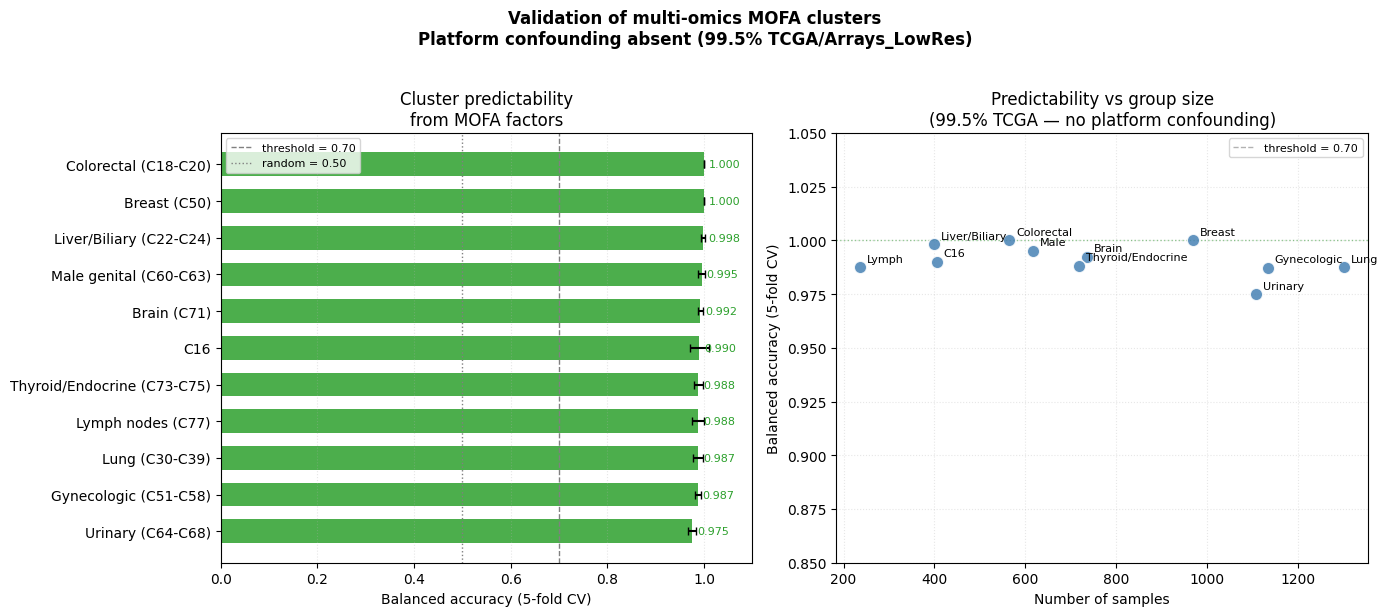

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: barplot bal_acc by group 
pred_sorted = pred_df.sort_values("bal_acc_mean", ascending=True)
colors = ["#d62728" if v < 0.7 else "#2ca02c"
          for v in pred_sorted["bal_acc_mean"]]

axes[0].barh(
    pred_sorted["cancer_group"],
    pred_sorted["bal_acc_mean"],
    xerr=pred_sorted["bal_acc_std"],
    color=colors, alpha=0.85, capsize=3, height=0.65
)
axes[0].axvline(0.7,  linestyle="--", color="grey",
                linewidth=1, label="threshold = 0.70")
axes[0].axvline(0.5,  linestyle=":",  color="grey",
                linewidth=1, label="random = 0.50")
axes[0].set_xlabel("Balanced accuracy (5-fold CV)")
axes[0].set_title("Cluster predictability\nfrom MOFA factors")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1.10)
axes[0].grid(axis="x", linestyle=":", alpha=0.3)

# Values annotation
for i, (_, row) in enumerate(pred_sorted.iterrows()):
    axes[0].text(
        row["bal_acc_mean"] + 0.01, i,
        f"{row['bal_acc_mean']:.3f}",
        va="center", fontsize=8,
        color="#2ca02c" if row["bal_acc_mean"] >= 0.7 else "#d62728"
    )

# Right panel : bal_acc vs n_samples 

merged = pred_df.merge(
    trust_df[["cancer_group", "plat_f1_from_mofa",
              "cramersV_cluster_src"]],
    on="cancer_group"
)

x = merged["n_samples"].astype(float)
y = merged["bal_acc_mean"].astype(float)

axes[1].scatter(x, y, s=80, alpha=0.85,
                color="steelblue", edgecolors="white", zorder=3)

for _, row in merged.iterrows():
    axes[1].annotate(
        row["cancer_group"].split(" ")[0],
        (row["n_samples"], row["bal_acc_mean"]),
        xytext=(5, 4), textcoords="offset points", fontsize=8
    )

# Reference Lign
axes[1].axhline(0.7,  linestyle="--", color="grey",
                linewidth=1, label="threshold = 0.70", alpha=0.6)
axes[1].axhline(1.0,  linestyle=":",  color="green",
                linewidth=1, alpha=0.4)

# Annotation with plat_f1 if available 
for _, row in merged.iterrows():
    if pd.notna(row["plat_f1_from_mofa"]):
        axes[1].annotate(
            f"plat_F1={row['plat_f1_from_mofa']:.2f}",
            (row["n_samples"], row["bal_acc_mean"]),
            xytext=(5, -14), textcoords="offset points",
            fontsize=7, color="grey"
        )

axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Balanced accuracy (5-fold CV)")
axes[1].set_title("Predictability vs group size\n"
                  "(99.5% TCGA — no platform confounding)")
axes[1].legend(fontsize=8)
axes[1].grid(linestyle=":", alpha=0.3)
axes[1].set_ylim(0.85, 1.05)

plt.suptitle(
    "Validation of multi-omics MOFA clusters\n"
    "Platform confounding absent (99.5% TCGA/Arrays_LowRes)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### Morphological stability of clusters 
For each cancer_group with >= 2 clusters:
- Are the morphologies distributed differently
- between the clusters? (Fisher's test / chi-square)
- If yes → the clusters capture actual histological subtypes

In [20]:
from scipy.stats import chi2_contingency

morph_test_rows = []

for cancer_group, df in group_tables.items():
    df_in = df[df[CLUSTER_COL] != OUTLIER].copy()
    if df_in[CLUSTER_COL].nunique() < 2:
        continue
    if MORPH_COL not in df_in.columns:
        continue

    # contingency table cluster × morphology
    tab = pd.crosstab(df_in[CLUSTER_COL], df_in[MORPH_COL])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue

    try:
        chi2, p, dof, _ = chi2_contingency(tab)
        cv = cramers_v(
            df_in[CLUSTER_COL].astype(str),
            df_in[MORPH_COL].astype(str)
        )
    except Exception:
        chi2, p, cv = np.nan, np.nan, np.nan

    morph_test_rows.append({
        "cancer_group":  cancer_group,
        "n_samples":     int(len(df_in)),
        "n_clusters":    int(df_in[CLUSTER_COL].nunique()),
        "n_morphologies": int(df_in[MORPH_COL].nunique()),
        "chi2":          chi2,
        "p_value":       p,
        "cramersV_morph": cv,
    })

morph_test_df = pd.DataFrame(morph_test_rows).sort_values(
    "cramersV_morph", ascending=False
)

print(" cluster x morphology association test ")
print(morph_test_df.round(4).to_string(index=False))

 cluster x morphology association test 
               cancer_group  n_samples  n_clusters  n_morphologies      chi2  p_value  cramersV_morph
     Male genital (C60-C63)        617           2              14  611.9606   0.0000          0.9959
Thyroid/Endocrine (C73-C75)        718           2              16  647.6218   0.0000          0.9497
                Brain (C71)        737           2               8  315.0095   0.0000          0.6538
          Urinary (C64-C68)       1109           8               8 2089.4404   0.0000          0.5188
      Gynecologic (C51-C58)       1134           6              26 1492.1959   0.0000          0.5130
             Lung (C30-C39)       1302           5              38 1257.0264   0.0000          0.4913
               Breast (C50)        969           2              21   52.4428   0.0001          0.2326
          Lymph nodes (C77)        237           2               5    9.3382   0.0532          0.1985
                        C16        405    

In [21]:
# Charger les résultats de validation prédictive du subtyping
sig_pred_df = pd.read_csv(
    BASE_DIR / "subtyping" / "signature_predictability.tsv",
    sep="\t"
)
print(f"Signature predictability chargée : {sig_pred_df.shape}")

Signature predictability chargée : (11, 9)


In [22]:
subtyping_qc = pd.read_csv(
    BASE_DIR / "subtyping" / "subtyping_qc.tsv",
    sep="\t"
)
print(f"Subtyping QC chargé : {subtyping_qc.shape}")

Subtyping QC chargé : (19, 12)


In [23]:
# ── Tableau de synthèse final ──────────────────────────────────────
# Regroupe toutes les métriques de validation en un seul tableau

validation_summary = (
    pred_df[["cancer_group", "n_samples", "n_clusters",
             "bal_acc_mean", "bal_acc_std"]]
    .merge(
        morph_test_df[["cancer_group", "cramersV_morph", "p_value"]],
        on="cancer_group", how="left"
    )
    .merge(
        sig_pred_df[["cancer_group", "n_factors_used",
                     "dominant_omics", "bal_acc_sig_mean"]],
        on="cancer_group", how="left"
    )
    .merge(
        subtyping_qc[["cancer_group", "morph_topfrac_weighted"]],
        on="cancer_group", how="left"
    )
    .sort_values("bal_acc_mean", ascending=False)
)

print("\n=== Validation Summary ===")
print(validation_summary[[
    "cancer_group",
    "n_samples",
    "n_clusters",
    "bal_acc_mean",          # prédictibilité 20 facteurs
    "bal_acc_sig_mean",      # prédictibilité facteurs discriminants
    "cramersV_morph",        # cohérence morphologique
    "morph_topfrac_weighted",# pureté morphologique
    "dominant_omics",        # omiques qui contribuent
]].to_string(index=False))

# Sauvegarde
validation_summary.to_csv(
    OUT_DIR / "validation_summary.tsv",
    sep="\t", index=False
)
print(f"\n[saved] validation_summary.tsv")


=== Validation Summary ===
               cancer_group  n_samples  n_clusters  bal_acc_mean  bal_acc_sig_mean  cramersV_morph  morph_topfrac_weighted dominant_omics
               Breast (C50)        969           2      1.000000          1.000000        0.232638                0.740970      Meth, RNA
       Colorectal (C18-C20)        565           2      1.000000          1.000000        0.151804                0.837168 Meth, RNA, CNV
    Liver/Biliary (C22-C24)        398           2      0.998148          0.998148        0.126841                0.866834 Meth, CNV, RNA
     Male genital (C60-C63)        617           2      0.995123          0.990256        0.995908                0.575365 Meth, RNA, CNV
                Brain (C71)        737           2      0.992440          0.995381        0.653775                0.386703 Meth, CNV, RNA
                        C16        405           2      0.990000          0.990000        0.155550                0.365432 Meth, CNV, RNA
Thyroi

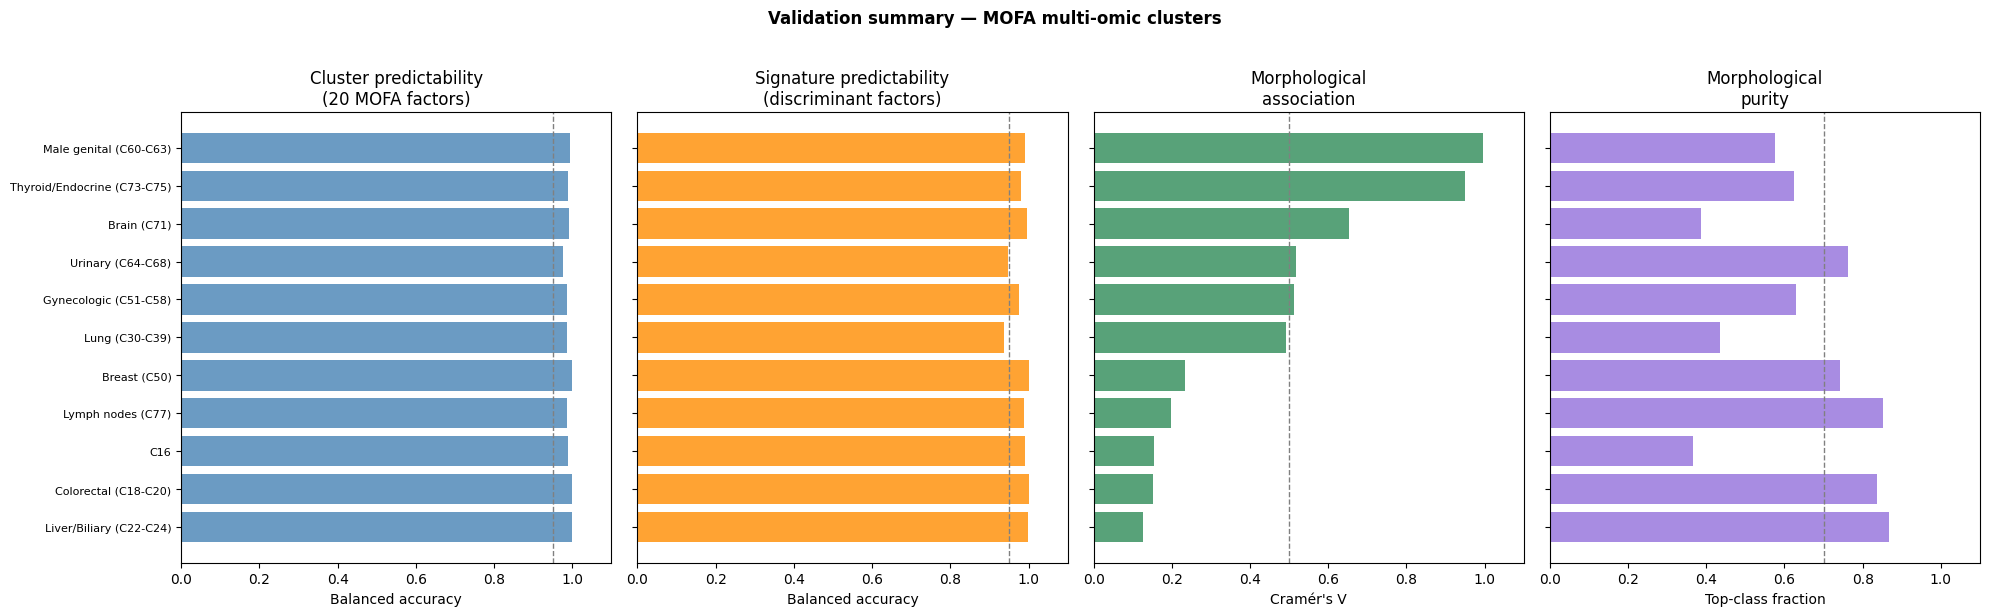

In [24]:
# ── Visualisation synthèse ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

df_viz = validation_summary.sort_values(
    "cramersV_morph", ascending=True
).copy()

groups    = df_viz["cancer_group"].tolist()
y_pos     = np.arange(len(groups))
bar_color = "steelblue"

# Panel 1 — bal_acc 20 facteurs
axes[0].barh(y_pos, df_viz["bal_acc_mean"],
             color=bar_color, alpha=0.8)
axes[0].axvline(0.95, linestyle="--", color="grey", linewidth=1)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(groups, fontsize=8)
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_title("Cluster predictability\n(20 MOFA factors)")
axes[0].set_xlim(0, 1.1)

# Panel 2 — bal_acc facteurs discriminants
axes[1].barh(y_pos, df_viz["bal_acc_sig_mean"],
             color="darkorange", alpha=0.8)
axes[1].axvline(0.95, linestyle="--", color="grey", linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([])
axes[1].set_xlabel("Balanced accuracy")
axes[1].set_title("Signature predictability\n(discriminant factors)")
axes[1].set_xlim(0, 1.1)

# Panel 3 — Cramér's V morphologie
axes[2].barh(y_pos, df_viz["cramersV_morph"].fillna(0),
             color="seagreen", alpha=0.8)
axes[2].axvline(0.5, linestyle="--", color="grey", linewidth=1)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels([])
axes[2].set_xlabel("Cramér's V")
axes[2].set_title("Morphological\nassociation")
axes[2].set_xlim(0, 1.1)

# Panel 4 — morph_topfrac_weighted
axes[3].barh(y_pos, df_viz["morph_topfrac_weighted"].fillna(0),
             color="mediumpurple", alpha=0.8)
axes[3].axvline(0.7, linestyle="--", color="grey", linewidth=1)
axes[3].set_yticks(y_pos)
axes[3].set_yticklabels([])
axes[3].set_xlabel("Top-class fraction")
axes[3].set_title("Morphological\npurity")
axes[3].set_xlim(0, 1.1)

plt.suptitle(
    "Validation summary — MOFA multi-omic clusters",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

In [25]:
# Sauvegarde finale
pred_df.to_csv(OUT_DIR / "cluster_predictability.tsv",
               sep="\t", index=False)
trust_df.to_csv(OUT_DIR / "platform_confounding.tsv",
                sep="\t", index=False)
morph_test_df.to_csv(OUT_DIR / "morphology_association.tsv",
                     sep="\t", index=False)
print("Validation notebook terminé.")

Validation notebook terminé.


In [26]:
# Vérifier les clusters générés par le bon notebook de clustering
CLUSTERS_DIR = Path("/Users/bgadmin/Downloads/cnv_preproc_release_v2/subtyping_leiden_A/clusters_by_root")
cluster_files = sorted([f.name for f in CLUSTERS_DIR.glob("*.parquet")])
print(f"{len(cluster_files)} fichiers clusters trouvés")
print(cluster_files)

20 fichiers clusters trouvés
['C00_C14_clusters_leiden_cpm.parquet', 'C15_C17_C21_C26_clusters_leiden_cpm.parquet', 'C16_clusters_leiden_cpm.parquet', 'C18_C20_clusters_leiden_cpm.parquet', 'C22_C24_clusters_leiden_cpm.parquet', 'C25_clusters_leiden_cpm.parquet', 'C30_C39_clusters_leiden_cpm.parquet', 'C40_C41_C48_clusters_leiden_cpm.parquet', 'C42_clusters_leiden_cpm.parquet', 'C44_clusters_leiden_cpm.parquet', 'C49_clusters_leiden_cpm.parquet', 'C50_clusters_leiden_cpm.parquet', 'C51_C58_clusters_leiden_cpm.parquet', 'C60_C63_clusters_leiden_cpm.parquet', 'C64_C68_clusters_leiden_cpm.parquet', 'C69_C70_C72_clusters_leiden_cpm.parquet', 'C71_clusters_leiden_cpm.parquet', 'C73_C75_clusters_leiden_cpm.parquet', 'C77_clusters_leiden_cpm.parquet', 'C80_clusters_leiden_cpm.parquet']
